# BrainInsight AI
# Notebook 07: Tumor Segmentation

## Objectives
Segment the tumor region using classical image processing (OpenCV only).

### Pipeline
1. Load MRI Image
2. Grayscale
3. Gaussian Blur
4. Otsu Thresholding
5. Morphological Opening
6. Morphological Closing
7. Contour Detection
8. Tumor Mask
9. Bounding Box
10. Tumor Measurements


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path("..")
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "segmented_images"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE=(256,256)


## Segmentation Function

In [2]:
def segment_tumor(image_path):
    image=cv2.imread(str(image_path))
    if image is None:
        raise ValueError("Unable to load image.")

    image=cv2.resize(image,TARGET_SIZE)
    gray=cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)
    blur=cv2.GaussianBlur(gray,(5,5),0)

    _,binary=cv2.threshold(
        blur,0,255,
        cv2.THRESH_BINARY+cv2.THRESH_OTSU
    )

    kernel=np.ones((3,3),np.uint8)
    opened=cv2.morphologyEx(binary,cv2.MORPH_OPEN,kernel)
    closed=cv2.morphologyEx(opened,cv2.MORPH_CLOSE,kernel)

    contours,_=cv2.findContours(
        closed,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    mask=np.zeros_like(gray)
    result=image.copy()

    measurements={}

    if contours:
        cnt=max(contours,key=cv2.contourArea)

        cv2.drawContours(mask,[cnt],-1,255,-1)

        x,y,w,h=cv2.boundingRect(cnt)
        cv2.rectangle(result,(x,y),(x+w,y+h),(0,255,0),2)

        area=cv2.contourArea(cnt)
        perimeter=cv2.arcLength(cnt,True)

        circularity=(4*np.pi*area)/(perimeter**2+1e-6)

        brightness=cv2.mean(gray,mask=mask)[0]

        edge=cv2.Canny(mask,100,200)
        edge_irregularity=np.count_nonzero(edge)/(perimeter+1e-6)

        texture=gray[mask>0].std() if np.any(mask>0) else 0

        tumor_percentage=(area/(gray.shape[0]*gray.shape[1]))*100

        measurements={
            "Tumor Area (px²)":area,
            "Tumor Percentage (%)":tumor_percentage,
            "Perimeter":perimeter,
            "Circularity":circularity,
            "Brightness":brightness,
            "Texture":texture,
            "Edge Irregularity":edge_irregularity
        }

    return image,gray,closed,mask,result,measurements


## Test Segmentation

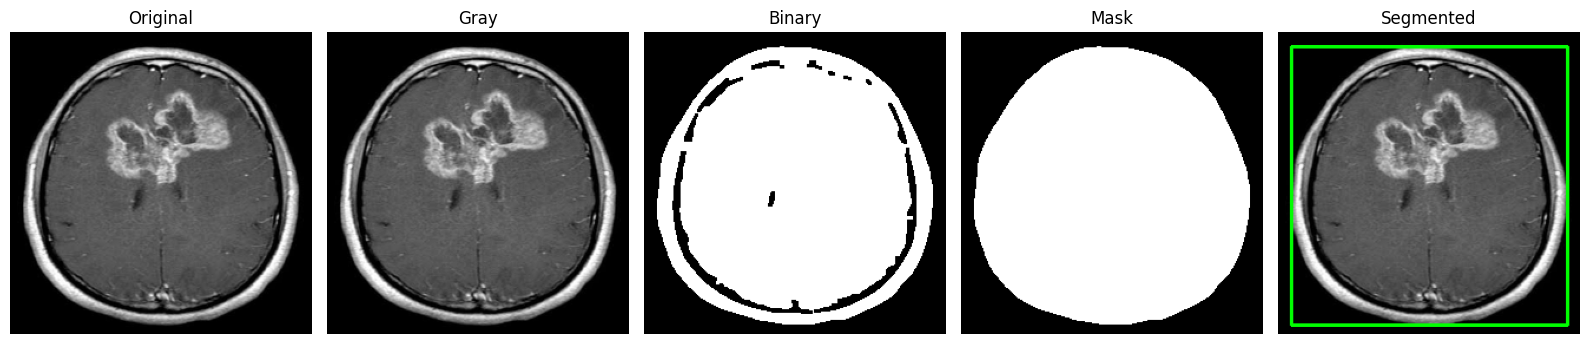

Tumor Measurements
Tumor Area (px²)         : 43381.00
Tumor Percentage (%)     : 66.19
Perimeter                : 783.70
Circularity              : 0.89
Brightness               : 98.44
Texture                  : 46.45
Edge Irregularity        : 0.98


In [3]:
# Replace with a valid MRI image
IMAGE_PATH=r"../dataset/Testing/glioma/Te-gl_1.jpg"

original,gray,binary,mask,result,measurements=segment_tumor(IMAGE_PATH)

titles=["Original","Gray","Binary","Mask","Segmented"]
images=[original,gray,binary,mask,result]

plt.figure(figsize=(16,4))

for i,(title,img) in enumerate(zip(titles,images),1):
    plt.subplot(1,5,i)
    if len(img.shape)==2:
        plt.imshow(img,cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

cv2.imwrite(str(OUTPUT_DIR/"segmented_result.png"),result)
cv2.imwrite(str(OUTPUT_DIR/"tumor_mask.png"),mask)

print("Tumor Measurements")
for k,v in measurements.items():
    print(f"{k:<25}: {v:.2f}")


## Conclusion

The tumor region has been segmented using OpenCV without deep learning. The generated tumor mask and measurements will be used in the next notebook to calculate the severity score.


## Interview Notes

- Why use Otsu Thresholding?
- Why apply Morphological Opening and Closing?
- Why choose the largest contour?
- How is tumor area calculated?
- What is circularity?
- Why measure edge irregularity?
